# Ranking-algorithm effects

This notebook presents the 14 substantive orderings under the loose, unpinned interface. Estimates are discussion-level means from the completed inference tables; intervals are the prespecified paired bootstrap intervals. The explicit random ordering is the zero-calibration reference and is not ranked as a deployable policy.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'commentgap_analysis').exists() and (REPO_ROOT.parent / 'commentgap_analysis').exists():
    REPO_ROOT = REPO_ROOT.parent
INFERENCE_ROOT = REPO_ROOT / 'model_output/selection_2025/forum_ranking_analysis/inference'
REPORTING_ROOT = REPO_ROOT / 'model_output/selection_2025/forum_ranking_analysis/reporting'


## Run the relevant analysis if needed

This notebook is executable on its own once the upstream FORUM/ranking analysis handoff and policy scores exist. It runs paired bootstrap inference when its required result files are missing; otherwise it reads the frozen inference products.


In [2]:
from commentgap_analysis.forum_scores import (
    DEFAULT_BOOTSTRAP_DRAWS, DEFAULT_RANDOM_DRAWS, DEFAULT_SEED,
    DEFAULT_TIE_DRAWS, run_policy_inference, run_policy_scoring
)

# Rebuild when policy semantics or the grouped metric schema have changed.
import json
from commentgap_analysis.forum_scores import FORUM_ANALYSIS_VERSION
analysis_comments_path = REPO_ROOT / 'model_output/selection_2025/forum_ranking_analysis/analysis_comments.parquet'
policy_scores_path = REPO_ROOT / 'model_output/selection_2025/forum_ranking_analysis/policy_scores/policy_scores.parquet'
inference_targets = [INFERENCE_ROOT / 'policy_summary.csv', INFERENCE_ROOT / 'marginal_effects.csv', INFERENCE_ROOT / 'forum_ndcg_agreement.csv']
agreement_path = INFERENCE_ROOT / 'forum_ndcg_agreement.csv'
metric_schema_current = agreement_path.exists() and 'variant_group' in pd.read_csv(agreement_path, nrows=0).columns

inference_manifest_path = INFERENCE_ROOT / 'inference_manifest.json'
policy_semantics_current = (
    inference_manifest_path.exists()
    and json.loads(inference_manifest_path.read_text()).get('version') == FORUM_ANALYSIS_VERSION
)
if not all(path.exists() for path in inference_targets) or not metric_schema_current or not policy_semantics_current:
    prerequisites = [analysis_comments_path, policy_scores_path]
    missing_prerequisites = [str(path) for path in prerequisites if not path.exists()]
    if missing_prerequisites:
        raise FileNotFoundError(
            'Inference inputs are missing: ' + ', '.join(missing_prerequisites) +
            '. Run notebook 10 to build the upstream handoff and policy scores.'
        )
    print('Inference products are missing or stale; refreshing policy scores and paired bootstrap inference...')
    run_policy_scoring(
        analysis_path=analysis_comments_path,
        output_root=REPO_ROOT / 'model_output/selection_2025/forum_ranking_analysis/policy_scores',
        tie_draws=DEFAULT_TIE_DRAWS, random_draws=DEFAULT_RANDOM_DRAWS, seed=DEFAULT_SEED,
        progress_every_stories=10,
    )
    run_policy_inference(
        policy_scores_path=policy_scores_path,
        analysis_comments_path=analysis_comments_path,
        output_root=INFERENCE_ROOT, bootstrap_draws=DEFAULT_BOOTSTRAP_DRAWS, seed=DEFAULT_SEED,
    )
else:
    print('Required grouped inference products already exist; reading them below.')


Required grouped inference products already exist; reading them below.


In [3]:
summary = pd.read_csv(INFERENCE_ROOT / 'policy_summary.csv')
effects = pd.read_csv(INFERENCE_ROOT / 'marginal_effects.csv')
agreement = pd.read_csv(INFERENCE_ROOT / 'forum_ndcg_agreement.csv')
print(f"{effects['outcome'].nunique()} outcomes; {effects['contrast'].nunique()} contrasts; samples={effects['sample'].unique().tolist()}")


46 outcomes; 17 contrasts; samples=['primary', 'large_threads']


## Policy rankings across ordering, reply structure, and pinning

The raw table below reports average FORUM for the loose, unpinned policies, including random. The next table ranks all 84 substantive ordering × reply-mode × pinning bundles. Both top-10 and full-depth results are shown.


In [4]:
for depth in ('top10', 'full'):
    print(f'Raw average FORUM: {depth}')
    raw_policy = summary[
        summary['sample'].eq('primary')
        & summary['depth'].eq(depth)
        & summary['reply_mode'].eq('loose')
        & ~summary['pinned']
    ].copy()
    raw_policy['interval'] = raw_policy.apply(lambda r: f"{r.estimate:.3f} [{r.ci_lower:.3f}, {r.ci_upper:.3f}]", axis=1)
    display(raw_policy[['ordering', 'estimate', 'ci_lower', 'ci_upper', 'probability_highest_forum', 'interval']].sort_values('estimate', ascending=False))


Raw average FORUM: top10


,ordering,estimate,ci_lower,ci_upper,probability_highest_forum,interval
5688,reverse_chronological,1.000000,1.000000,1.000000,1.0000,"1.000 [1.000, 1.000]"
6228,reverse_chronological,0.952566,0.947448,0.957288,1.0000,"0.953 [0.947, 0.957]"
840,regression_editor,0.682320,0.676233,0.688215,0.9975,"0.682 [0.676, 0.688]"
852,xgb_metadata_editor,0.677321,0.671169,0.683511,0.0025,"0.677 [0.671, 0.684]"
864,xgb_metadata_text_editor,0.672792,0.666650,0.679121,0.0000,"0.673 [0.667, 0.679]"
...,...,...,...,...,...,...
4998,xgb_metadata_text_audience,-0.999014,-0.999374,-0.998597,0.0000,"-0.999 [-0.999, -0.999]"
4992,xgb_metadata_editor,-0.999339,-0.999630,-0.998988,0.0000,"-0.999 [-1.000, -0.999]"
5004,xgb_metadata_text_editor,-0.999449,-0.999679,-0.999173,0.0000,"-0.999 [-1.000, -0.999]"
4980,regression_editor,-0.999518,-0.999770,-0.999199,0.0000,"-1.000 [-1.000, -0.999]"


Raw average FORUM: full


,ordering,estimate,ci_lower,ci_upper,probability_highest_forum,interval
5598,reverse_chronological,1.000000,1.000000,1.000000,1.0,"1.000 [1.000, 1.000]"
6138,reverse_chronological,0.938293,0.933003,0.943068,1.0,"0.938 [0.933, 0.943]"
3858,neural_metadata_text_editor,0.448206,0.443849,0.452366,1.0,"0.448 [0.444, 0.452]"
5418,reverse_chronological,0.433815,0.428425,0.439414,1.0,"0.434 [0.428, 0.439]"
3810,regression_editor,0.427556,0.423378,0.431582,0.0,"0.428 [0.423, 0.432]"
...,...,...,...,...,...,...
4896,xgb_metadata_audience,-0.985982,-0.986739,-0.985160,0.0,"-0.986 [-0.987, -0.985]"
4908,xgb_metadata_text_audience,-0.988598,-0.989099,-0.988078,0.0,"-0.989 [-0.989, -0.988]"
4914,xgb_metadata_text_editor,-0.991877,-0.992240,-0.991509,0.0,"-0.992 [-0.992, -0.992]"
4902,xgb_metadata_editor,-0.992149,-0.992532,-0.991752,0.0,"-0.992 [-0.993, -0.992]"


In [5]:
for depth in ('top10', 'full'):
    ranked = summary[
        summary['sample'].eq('primary')
        & summary['depth'].eq(depth)
        & summary['deployable']
    ].copy()
    ranked['rank_within_outcome'] = ranked.groupby('outcome')['estimate'].rank(method='min', ascending=False).astype(int)
    print(f'Top substantive policy bundles by outcome: {depth}')
    display(ranked[ranked['rank_within_outcome'] <= 10].sort_values(['outcome', 'rank_within_outcome'])[[
        'outcome', 'rank_within_outcome', 'ordering', 'reply_mode', 'pinned',
        'estimate', 'ci_lower', 'ci_upper'
    ]])


Top substantive policy bundles by outcome: top10


,outcome,rank_within_outcome,ordering,reply_mode,pinned,estimate,ci_lower,ci_upper
168,aqua_additional_knowledge_expected,1,neural_metadata_text_editor,loose,False,0.339576,0.332086,0.346703
172,aqua_additional_knowledge_expected,2,neural_metadata_text_editor,hidden,False,0.336012,0.328565,0.343126
120,aqua_additional_knowledge_expected,3,regression_editor,loose,False,0.329787,0.322919,0.336839
124,aqua_additional_knowledge_expected,4,regression_editor,hidden,False,0.329474,0.322647,0.336504
132,aqua_additional_knowledge_expected,5,xgb_metadata_editor,loose,False,0.321761,0.314582,0.328155
...,...,...,...,...,...,...,...,...
8213,vienna_weekend_day_evening,6,reverse_chronological,hidden,True,-0.285968,-0.305991,-0.265104
8192,vienna_weekend_day_evening,7,relative_votes,trees,False,-0.360278,-0.385821,-0.335961
8198,vienna_weekend_day_evening,8,upvotes,trees,False,-0.361454,-0.386569,-0.337903
8270,vienna_weekend_day_evening,9,neural_metadata_text_editor,trees,False,-0.375691,-0.402333,-0.349665


Top substantive policy bundles by outcome: full


,outcome,rank_within_outcome,ordering,reply_mode,pinned,estimate,ci_lower,ci_upper
78,aqua_additional_knowledge_expected,1,neural_metadata_text_editor,loose,False,0.367229,0.363244,0.371351
66,aqua_additional_knowledge_expected,2,neural_metadata_editor,loose,False,0.348386,0.344675,0.352213
54,aqua_additional_knowledge_expected,3,xgb_metadata_text_editor,loose,False,0.272026,0.267710,0.276499
30,aqua_additional_knowledge_expected,4,regression_editor,loose,False,0.267749,0.263199,0.272499
48,aqua_additional_knowledge_expected,5,xgb_metadata_text_audience,loose,False,0.266373,0.262043,0.270849
...,...,...,...,...,...,...,...,...
8122,vienna_weekend_day_evening,6,reverse_chronological,hidden,False,-0.059690,-0.072758,-0.046585
8123,vienna_weekend_day_evening,7,reverse_chronological,hidden,True,-0.063316,-0.075843,-0.050382
8108,vienna_weekend_day_evening,8,upvotes,trees,False,-0.082048,-0.096690,-0.066803
8103,vienna_weekend_day_evening,9,relative_votes,trees,True,-0.111234,-0.125875,-0.096900


In [6]:
for depth in ('top10', 'full'):
    primary = effects[
        effects['sample'].eq('primary')
        & effects['depth'].eq(depth)
        & effects['contrast_family'].eq('ordering_vs_random')
    ].copy()
    primary['interval'] = primary.apply(lambda r: f"{r.estimate:.3f} [{r.ci_lower:.3f}, {r.ci_upper:.3f}]", axis=1)
    print(f'Ordering-versus-random contrasts: {depth}')
    display(primary.pivot(index='contrast', columns='outcome', values='interval'))


Ordering-versus-random contrasts: top10


outcome,aqua_additional_knowledge_expected,aqua_discrimination_expected,aqua_fact_expected,aqua_insult_expected,aqua_justification_expected,aqua_opinion_expected,aqua_polite_address_expected,aqua_question_expected,aqua_referencing_contents_expected,aqua_referencing_format_expected,...,reply_depth_centered,semantic_novelty_knn5,sentiment_negative,sentiment_positive,smog_de,toxicity_probability,url_present,vienna_overnight,vienna_weekday_shoulder_evening,vienna_weekend_day_evening
contrast,,,,,,,,,,,,,,,,,,,,,
chronological,"-0.072 [-0.079, -0.066]","-0.037 [-0.042, -0.033]","-0.061 [-0.066, -0.055]","-0.019 [-0.024, -0.015]","-0.085 [-0.091, -0.078]","-0.020 [-0.026, -0.015]","-0.001 [-0.008, 0.006]","-0.011 [-0.020, -0.003]","-0.029 [-0.034, -0.024]","-0.018 [-0.022, -0.014]",...,"-0.003 [-0.006, -0.001]","-0.012 [-0.017, -0.008]","-0.014 [-0.021, -0.007]","0.031 [0.023, 0.039]","-0.033 [-0.038, -0.029]","-0.032 [-0.042, -0.022]","-0.025 [-0.033, -0.017]","0.063 [0.047, 0.079]","-0.133 [-0.149, -0.118]","-0.017 [-0.026, -0.008]"
neural_metadata_audience,"0.156 [0.151, 0.161]","0.116 [0.112, 0.119]","0.169 [0.164, 0.173]","0.063 [0.059, 0.066]","0.258 [0.253, 0.263]","0.170 [0.166, 0.175]","0.134 [0.127, 0.141]","-0.063 [-0.071, -0.055]","0.011 [0.006, 0.017]","0.069 [0.065, 0.073]",...,"0.017 [0.015, 0.019]","-0.138 [-0.142, -0.134]","0.081 [0.075, 0.087]","-0.018 [-0.025, -0.010]","0.088 [0.085, 0.091]","0.044 [0.035, 0.054]","-0.058 [-0.064, -0.051]","0.034 [0.020, 0.047]","-0.076 [-0.090, -0.062]","-0.017 [-0.025, -0.008]"
neural_metadata_editor,"0.178 [0.173, 0.182]","0.099 [0.096, 0.103]","0.176 [0.172, 0.181]","0.052 [0.048, 0.055]","0.264 [0.260, 0.269]","0.152 [0.148, 0.157]","0.172 [0.166, 0.179]","-0.073 [-0.080, -0.065]","0.017 [0.011, 0.022]","0.103 [0.099, 0.107]",...,"0.021 [0.019, 0.023]","-0.145 [-0.149, -0.141]","-0.041 [-0.047, -0.035]","0.092 [0.085, 0.100]","0.090 [0.087, 0.093]","-0.086 [-0.094, -0.078]","0.074 [0.064, 0.085]","0.022 [0.009, 0.035]","-0.071 [-0.085, -0.058]","-0.017 [-0.025, -0.008]"
neural_metadata_text_audience,"0.154 [0.150, 0.159]","0.135 [0.131, 0.138]","0.164 [0.160, 0.168]","0.083 [0.080, 0.086]","0.257 [0.252, 0.262]","0.191 [0.186, 0.195]","0.115 [0.109, 0.122]","-0.102 [-0.109, -0.094]","-0.062 [-0.067, -0.057]","0.058 [0.054, 0.061]",...,"0.016 [0.014, 0.018]","-0.137 [-0.141, -0.133]","0.062 [0.056, 0.069]","0.008 [0.000, 0.016]","0.098 [0.094, 0.101]","0.109 [0.098, 0.119]","-0.058 [-0.065, -0.052]","-0.002 [-0.013, 0.010]","-0.039 [-0.052, -0.026]","-0.017 [-0.025, -0.008]"
neural_metadata_text_editor,"0.192 [0.188, 0.197]","0.128 [0.125, 0.132]","0.196 [0.192, 0.200]","0.059 [0.056, 0.063]","0.298 [0.293, 0.302]","0.187 [0.183, 0.192]","0.151 [0.144, 0.158]","-0.101 [-0.109, -0.094]","-0.040 [-0.045, -0.035]","0.081 [0.077, 0.084]",...,"0.019 [0.017, 0.021]","-0.160 [-0.164, -0.156]","0.010 [0.003, 0.016]","0.029 [0.022, 0.038]","0.109 [0.106, 0.112]","-0.021 [-0.030, -0.012]","0.030 [0.020, 0.041]","-0.021 [-0.031, -0.011]","-0.028 [-0.041, -0.015]","-0.015 [-0.023, -0.007]"
regression_audience,"0.137 [0.132, 0.142]","0.121 [0.117, 0.125]","0.156 [0.152, 0.161]","0.060 [0.057, 0.064]","0.261 [0.256, 0.265]","0.175 [0.170, 0.179]","0.112 [0.105, 0.119]","-0.106 [-0.114, -0.099]","-0.047 [-0.052, -0.042]","0.046 [0.043, 0.049]",...,"0.018 [0.016, 0.020]","-0.136 [-0.140, -0.132]","0.056 [0.050, 0.062]","0.010 [0.002, 0.018]","0.102 [0.098, 0.105]","0.070 [0.060, 0.080]","-0.076 [-0.081, -0.070]","0.043 [0.030, 0.058]","-0.087 [-0.102, -0.073]","-0.016 [-0.024, -0.007]"
regression_editor,"0.189 [0.184, 0.193]","0.129 [0.125, 0.133]","0.197 [0.193, 0.202]","0.045 [0.042, 0.049]","0.318 [0.314, 0.323]","0.204 [0.200, 0.208]","0.168 [0.161, 0.175]","-0.124 [-0.131, -0.117]","-0.031 [-0.036, -0.026]","0.076 [0.072, 0.079]",...,"0.020 [0.018, 0.022]","-0.169 [-0.173, -0.165]","-0.001 [-0.007, 0.004]","0.053 [0.045, 0.061]","0.117 [0.114, 0.121]","-0.039 [-0.048, -0.030]","0.048 [0.

Ordering-versus-random contrasts: full


outcome,aqua_additional_knowledge_expected,aqua_discrimination_expected,aqua_fact_expected,aqua_insult_expected,aqua_justification_expected,aqua_opinion_expected,aqua_polite_address_expected,aqua_question_expected,aqua_referencing_contents_expected,aqua_referencing_format_expected,...,reply_depth_centered,semantic_novelty_knn5,sentiment_negative,sentiment_positive,smog_de,toxicity_probability,url_present,vienna_overnight,vienna_weekday_shoulder_evening,vienna_weekend_day_evening
contrast,,,,,,,,,,,,,,,,,,,,,
chronological,"-0.033 [-0.036, -0.031]","-0.021 [-0.023, -0.019]","-0.027 [-0.029, -0.025]","-0.014 [-0.016, -0.011]","-0.034 [-0.036, -0.031]","-0.016 [-0.018, -0.014]","-0.014 [-0.017, -0.010]","-0.001 [-0.004, 0.001]","-0.012 [-0.015, -0.010]","-0.017 [-0.019, -0.015]",...,"-0.073 [-0.076, -0.071]","-0.004 [-0.006, -0.001]","-0.005 [-0.007, -0.003]","0.008 [0.005, 0.011]","-0.017 [-0.019, -0.015]","-0.019 [-0.023, -0.014]","-0.043 [-0.051, -0.035]","-0.208 [-0.220, -0.196]","-0.100 [-0.114, -0.085]","-0.175 [-0.191, -0.159]"
neural_metadata_audience,"0.093 [0.090, 0.095]","0.080 [0.078, 0.082]","0.115 [0.113, 0.117]","0.049 [0.047, 0.051]","0.124 [0.121, 0.126]","0.052 [0.050, 0.055]","0.051 [0.048, 0.054]","-0.034 [-0.036, -0.031]","-0.032 [-0.034, -0.030]","0.048 [0.046, 0.050]",...,"-0.108 [-0.110, -0.105]","-0.081 [-0.084, -0.079]","0.032 [0.029, 0.034]","-0.025 [-0.028, -0.022]","0.090 [0.088, 0.092]","0.013 [0.009, 0.017]","-0.022 [-0.028, -0.015]","-0.167 [-0.178, -0.156]","-0.078 [-0.091, -0.066]","-0.147 [-0.161, -0.134]"
neural_metadata_editor,"0.143 [0.141, 0.145]","0.082 [0.080, 0.084]","0.146 [0.144, 0.148]","0.038 [0.036, 0.040]","0.158 [0.156, 0.161]","0.065 [0.062, 0.067]","0.087 [0.083, 0.090]","-0.040 [-0.042, -0.037]","-0.028 [-0.030, -0.026]","0.088 [0.086, 0.091]",...,"-0.070 [-0.073, -0.067]","-0.116 [-0.119, -0.114]","-0.012 [-0.014, -0.010]","0.007 [0.004, 0.010]","0.123 [0.121, 0.124]","-0.027 [-0.031, -0.022]","0.142 [0.136, 0.148]","-0.139 [-0.149, -0.129]","-0.075 [-0.086, -0.064]","-0.137 [-0.149, -0.125]"
neural_metadata_text_audience,"0.079 [0.077, 0.081]","0.081 [0.079, 0.083]","0.102 [0.100, 0.104]","0.051 [0.049, 0.053]","0.115 [0.112, 0.117]","0.057 [0.055, 0.059]","0.046 [0.043, 0.050]","-0.034 [-0.036, -0.031]","-0.054 [-0.056, -0.052]","0.034 [0.032, 0.036]",...,"-0.093 [-0.096, -0.090]","-0.082 [-0.084, -0.079]","0.035 [0.033, 0.037]","-0.023 [-0.026, -0.020]","0.086 [0.084, 0.088]","0.049 [0.044, 0.053]","-0.034 [-0.040, -0.028]","-0.167 [-0.176, -0.157]","-0.077 [-0.089, -0.065]","-0.136 [-0.149, -0.124]"
neural_metadata_text_editor,"0.147 [0.145, 0.149]","0.112 [0.110, 0.114]","0.164 [0.162, 0.166]","0.053 [0.051, 0.055]","0.188 [0.185, 0.190]","0.095 [0.093, 0.097]","0.060 [0.057, 0.064]","-0.067 [-0.069, -0.064]","-0.050 [-0.052, -0.048]","0.063 [0.061, 0.065]",...,"-0.051 [-0.054, -0.048]","-0.133 [-0.136, -0.131]","0.020 [0.018, 0.022]","-0.021 [-0.024, -0.018]","0.131 [0.129, 0.133]","0.006 [0.002, 0.010]","0.081 [0.074, 0.087]","-0.142 [-0.151, -0.133]","-0.073 [-0.083, -0.063]","-0.124 [-0.136, -0.113]"
regression_audience,"0.078 [0.076, 0.080]","0.089 [0.087, 0.091]","0.107 [0.105, 0.110]","0.055 [0.053, 0.057]","0.133 [0.130, 0.135]","0.085 [0.083, 0.087]","0.051 [0.047, 0.054]","-0.055 [-0.058, -0.053]","-0.047 [-0.048, -0.045]","0.033 [0.031, 0.035]",...,"-0.102 [-0.105, -0.099]","-0.100 [-0.103, -0.098]","0.036 [0.033, 0.038]","-0.001 [-0.004, 0.002]","0.084 [0.082, 0.085]","0.034 [0.029, 0.038]","-0.098 [-0.104, -0.092]","-0.140 [-0.150, -0.129]","-0.067 [-0.079, -0.056]","-0.128 [-0.141, -0.115]"
regression_editor,"0.129 [0.126, 0.131]","0.118 [0.116, 0.120]","0.153 [0.151, 0.155]","0.063 [0.061, 0.065]","0.194 [0.191, 0.196]","0.121 [0.119, 0.124]","0.093 [0.089, 0.097]","-0.079 [-0.082, -0.077]","-0.037 [-0.039, -0.035]","0.061 [0.059, 0.063]",...,"-0.078 [-0.082, -0.075]","-0.136 [-0.138, -0.133]","0.023 [0.020, 0.025]","0.018 [0.015, 0.022]","0.116 [0.114, 0.11

Combined ordering and average interface effects figure: top 10 and full discussion


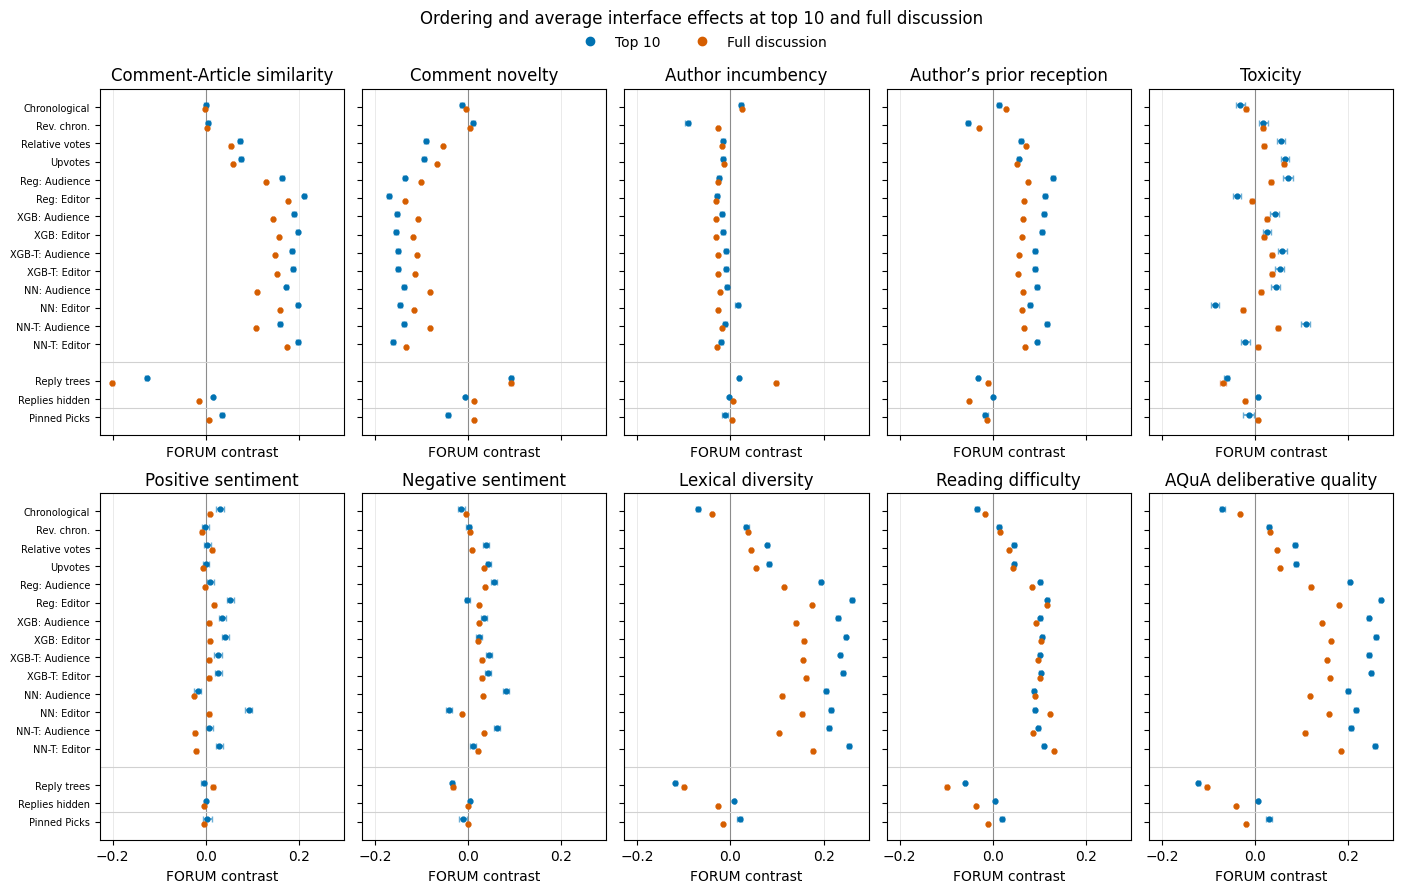

Ordering × reply × pin figure: top 10 and full discussion


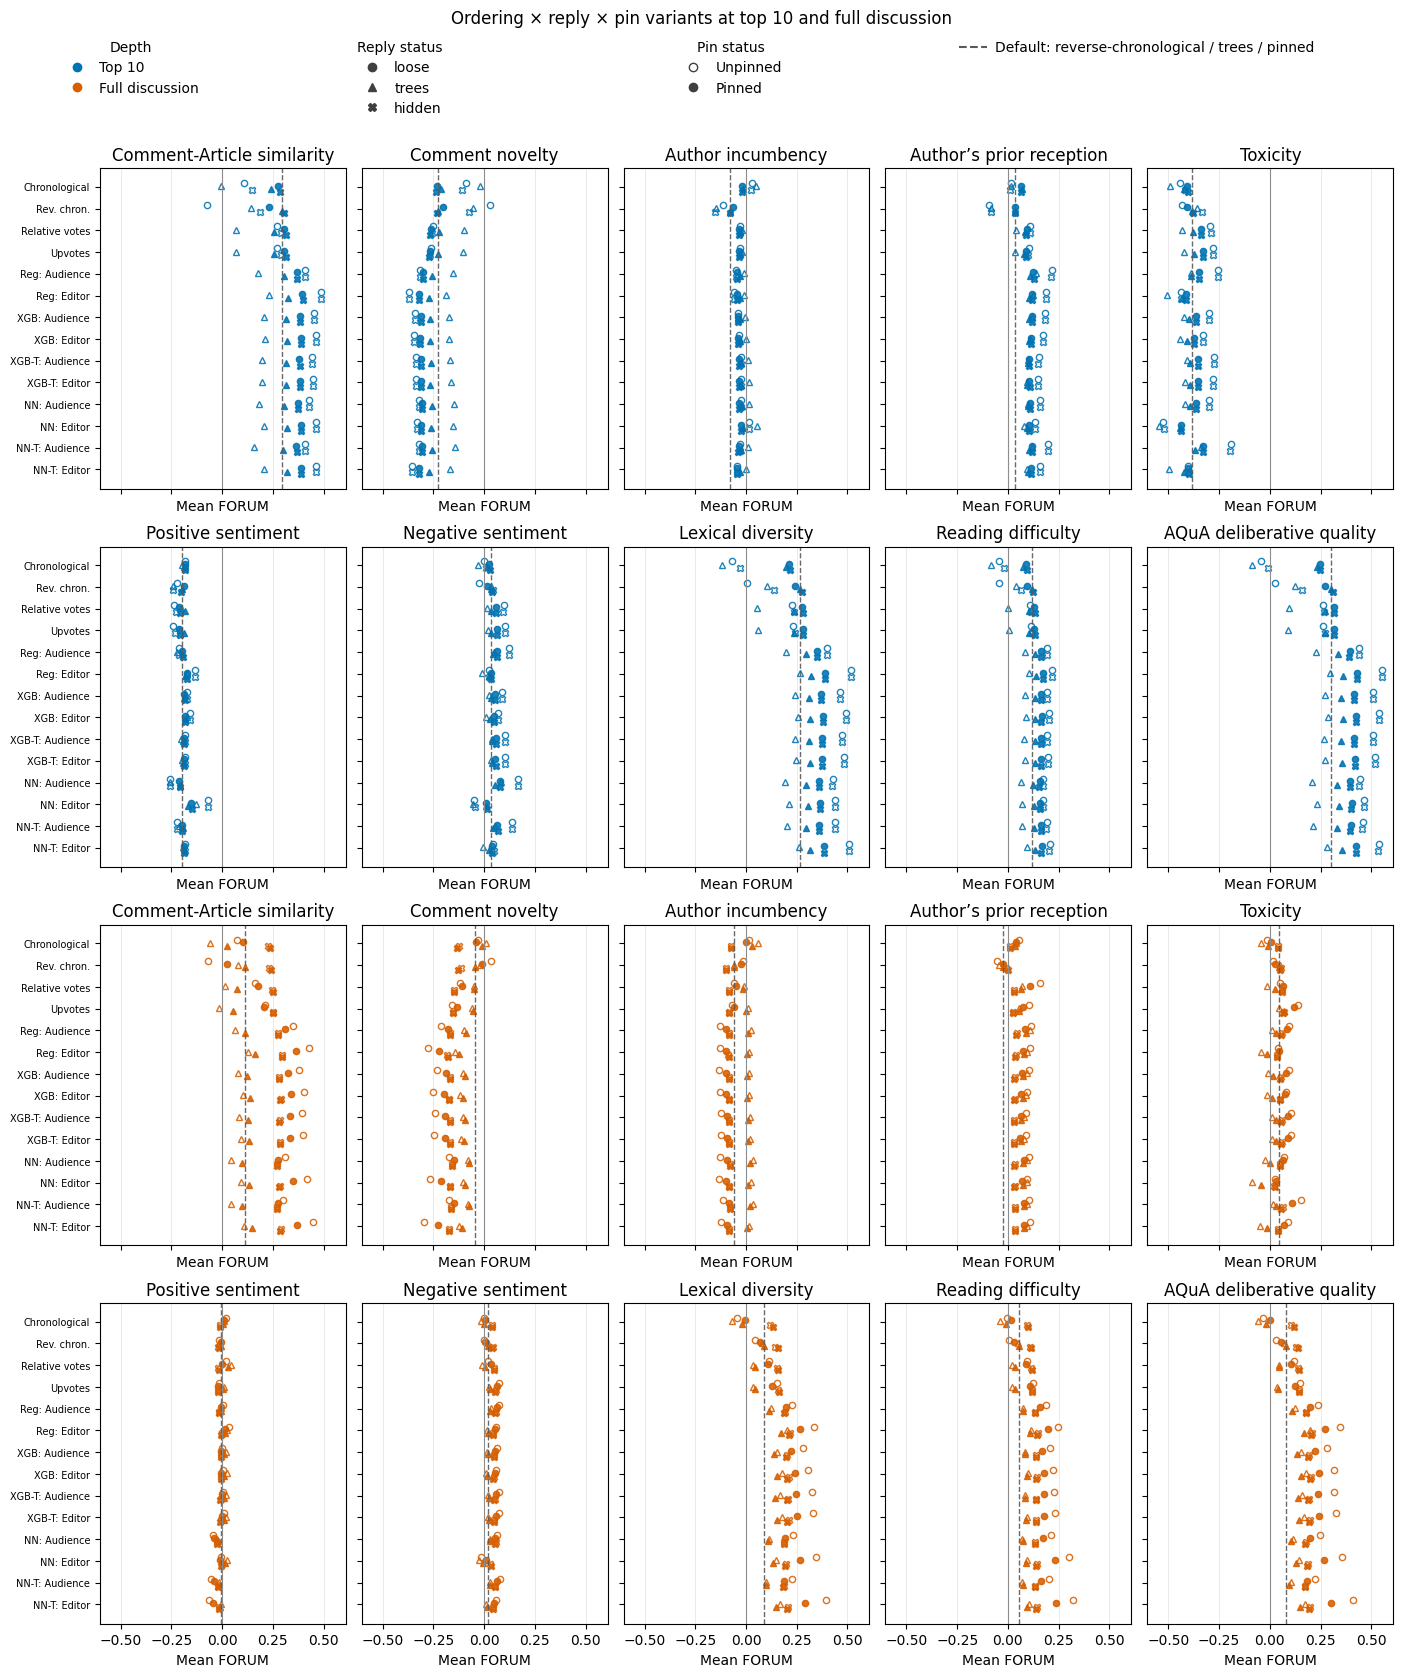

[PosixPath('/home/patrick/Documents/commentgap/model_output/selection_2025/forum_ranking_analysis/reporting/figure_ordering_policy_variants.pdf'),
 PosixPath('/home/patrick/Documents/commentgap/model_output/selection_2025/forum_ranking_analysis/reporting/figure_ordering_policy_variants.png')]

In [7]:
import importlib
import commentgap_analysis.ranking_algorithm_effects as ranking_effects
importlib.reload(ranking_effects)
plot_combined_ordering_effects = ranking_effects.plot_combined_ordering_effects
plot_ordering_policy_variants = ranking_effects.plot_ordering_policy_variants

print('Combined ordering and average interface effects figure: top 10 and full discussion')
plot_combined_ordering_effects(effects, REPORTING_ROOT, show=True)

print('Ordering × reply × pin figure: top 10 and full discussion')
plot_ordering_policy_variants(summary, REPORTING_ROOT, show=True)


## FORUM versus direct nDCG

nDCG is a standard discounted-cumulative-gain measure for ranked lists with binary or graded relevance (Järvelin & Kekäläinen, 2002, [doi:10.1145/582415.582418](https://doi.org/10.1145/582415.582418)). Here the continuous comment outcome is used as a graded gain after within-discussion min–max scaling, with linear rather than exponential gain. This is an adaptation of standard nDCG, not a new metric.


FORUM/nDCG agreement: top10


,outcome,variant_group,reply_mode,pinned,n_stories,n_orderings,spearman_forum_ndcg,ci_lower,ci_upper
7,aqua_additional_knowledge_expected,overall,NaN,NaN,2556,84,0.992103,0.988762,0.994897
8,aqua_additional_knowledge_expected,loose | unpinned,loose,False,2556,14,0.995604,0.991209,1.000000
9,aqua_additional_knowledge_expected,loose | pinned,loose,True,2556,14,1.000000,0.986813,1.000000
10,aqua_additional_knowledge_expected,trees | unpinned,trees,False,2556,14,0.995604,0.978022,1.000000
11,aqua_additional_knowledge_expected,trees | pinned,trees,True,2556,14,0.995604,0.973516,0.995604
...,...,...,...,...,...,...,...,...,...
639,vienna_weekend_day_evening,loose | pinned,loose,True,2040,14,0.951648,0.349451,0.978022
640,vienna_weekend_day_evening,trees | unpinned,trees,False,2040,14,0.916484,0.582418,0.978022
641,vienna_weekend_day_evening,trees | pinned,trees,True,2040,14,0.951648,0.551648,0.969231
642,vienna_weekend_day_evening,hidden | unpinned,hidden,False,2040,14,0.951648,0.701099,0.991209


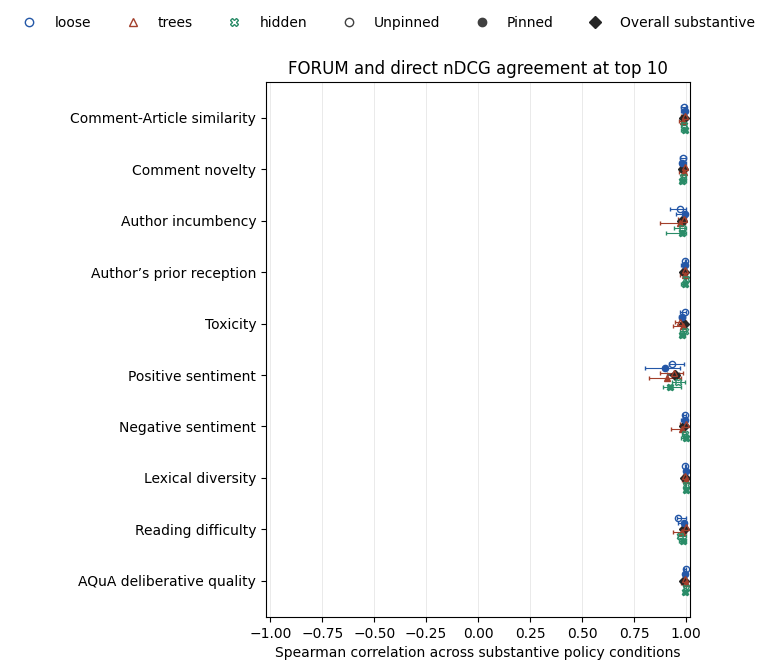

FORUM/nDCG agreement: full


,outcome,variant_group,reply_mode,pinned,n_stories,n_orderings,spearman_forum_ndcg,ci_lower,ci_upper
0,aqua_additional_knowledge_expected,overall,NaN,NaN,2556,84,0.955148,0.949903,0.959523
1,aqua_additional_knowledge_expected,loose | unpinned,loose,False,2556,14,0.978022,0.964835,0.978022
2,aqua_additional_knowledge_expected,loose | pinned,loose,True,2556,14,1.000000,0.995604,1.000000
3,aqua_additional_knowledge_expected,trees | unpinned,trees,False,2556,14,0.969231,0.951648,0.982418
4,aqua_additional_knowledge_expected,trees | pinned,trees,True,2556,14,0.982418,0.969121,0.991209
...,...,...,...,...,...,...,...,...,...
632,vienna_weekend_day_evening,loose | pinned,loose,True,2040,14,0.942857,0.920879,0.978022
633,vienna_weekend_day_evening,trees | unpinned,trees,False,2040,14,0.991209,0.942857,0.995604
634,vienna_weekend_day_evening,trees | pinned,trees,True,2040,14,0.964835,0.912088,0.982418
635,vienna_weekend_day_evening,hidden | unpinned,hidden,False,2040,14,0.978022,0.907692,0.995604


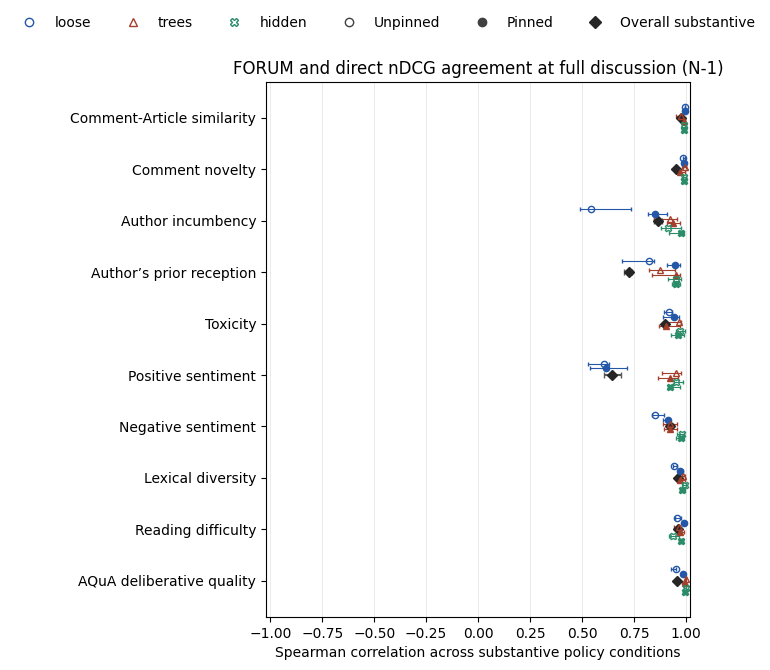

In [8]:
from commentgap_analysis.ranking_algorithm_effects import plot_metric_agreement

for depth in ('top10', 'full'):
    agreement_view = agreement[
        agreement['sample'].eq('primary') & agreement['depth'].eq(depth)
    ].copy()
    print(f'FORUM/nDCG agreement: {depth}')
    display(agreement_view[['outcome', 'variant_group', 'reply_mode', 'pinned', 'n_stories', 'n_orderings', 'spearman_forum_ndcg', 'ci_lower', 'ci_upper']])
    plot_metric_agreement(agreement, REPORTING_ROOT, depth=depth, show=True)
